In [54]:
import sklearn.decomposition as sk_decomp
from sklearn.cluster import k_means
import ants
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from petpal.preproc.image_operations_4d import extract_tac_from_nifty_using_mask, threshold
from petpal.utils.time_activity_curve import TimeActivityCurveFromFile
import nibabel
from scipy.stats import ttest_ind, zscore

In [2]:
pet_file = '/export/scratch1/PETPAL/03Dec24/sub-VATDYS017/sub-VATDYS017_reg.nii.gz'
seg_file = '/export/scratch1/PETPAL/03Dec24/sub-VATDYS017/sub-VATDYS017_wm-merged.nii.gz'
pet = ants.image_read(pet_file)
seg = ants.image_read(seg_file)

In [3]:
tac_example = TimeActivityCurveFromFile('/export/scratch1/PETPAL/03Dec24/sub-VATDYS017/tacs/ctxlhlingual_tac.tsv')

In [4]:
def region_blend(segmentation_numpy: np.ndarray,
                 regions_list: list):
    """
    Takes a list of regions and a segmentation, and returns a mask with only the listed regions.

    Args:
        segmentation_numpy (np.ndarray): Segmentation image data array
        regions_list (list): List of regions to include in the mask

    Returns:
        regions_blend (np.ndarray): Mask array with value one where
            segmentation values are in the list of regions provided, and zero
            elsewhere.
    """
    regions_blend = np.zeros(segmentation_numpy.shape)
    for region in regions_list:
        region_mask = segmentation_numpy == region
        region_mask_int = region_mask.astype(int)
        regions_blend += region_mask_int
    return regions_blend

In [5]:
def get_region_mask(segmentation: np.ndarray,
                    region: int):
    """

    """
    if isinstance(segmentation,ants.ANTsImage):
        segmentation = segmentation.numpy()
    mask = np.zeros(segmentation.shape)
    mask[np.where(segmentation==region)] = 1
    return mask

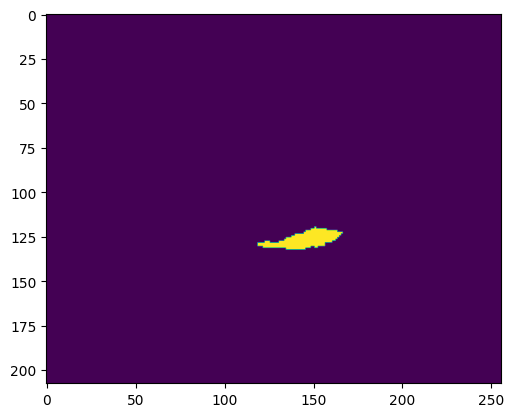

In [6]:
mask1 = get_region_mask(segmentation=seg,region=51)
plt.imshow(mask1[:,:,128],vmin=0,vmax=1)

In [7]:
def get_regions_mask(segmentation: np.ndarray,
                     regions: list[int]):
    mask = np.zeros(segmentation.shape)
    for region in regions:
        mask += get_region_mask(segmentation=segmentation,region=region)
    return mask

In [8]:
mask2 = get_regions_mask(segmentation=seg,regions=[12,51])

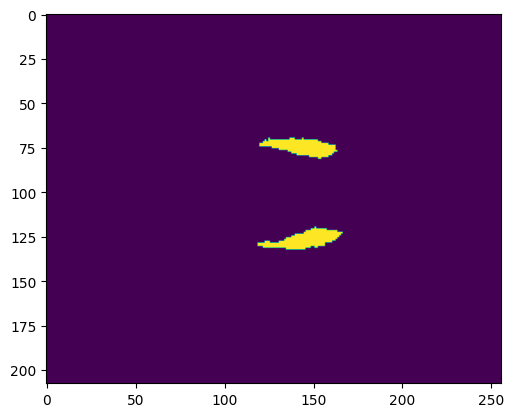

In [9]:
plt.imshow(mask2[:,:,128],vmin=0,vmax=1)

In [10]:
def apply_mask_3d(image: np.ndarray, mask: np.ndarray):
    """
    Applies a mask to a 3D image.
    """
    if len(image.shape)!=3:
        raise ValueError(f"Image must be 3D. Got: {len(image.shape)} dimensions.")

    image_masked = np.zeros(image.shape)
    image_masked[np.where(mask>0)] = image[np.where(mask>0)]
    return image_masked

In [11]:
pet_masked = apply_mask_3d(image=pet.numpy()[:,:,:,-1],mask=mask2)

In [12]:
pet_masked.shape

(208, 256, 256)

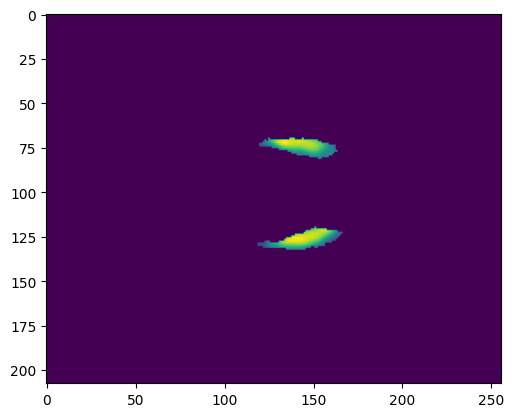

In [13]:
plt.imshow(pet_masked[:,:,128])

In [14]:
def check_image_dimensions(image: np.ndarray, dimension: int):
    """
    Check number of dimensions in an image array. Raise ValueError if not equal
    to the provided dimension.
    """
    if len(image.shape)!=dimension:
        raise ValueError(f"Image must be {dimension}D. Got: {len(image.shape)} dimensions.")

In [15]:
def get_number_of_frames(image: np.ndarray):
    """
    Get number of time frames in a 4D time series array.
    """
    check_image_dimensions(image=image,dimension=4)
    return image.shape[-1]

In [16]:
def apply_mask_4d(image: np.ndarray, mask: np.ndarray):
    """
    Apply a mask to a 4D image
    """
    check_image_dimensions(image=image,dimension=4)
    image_masked = np.zeros(image.shape)
    number_frames = get_number_of_frames(image=image)

    for frame in range(number_frames):
        masked_frame = apply_mask_3d(image=image[:,:,:,frame],mask=mask)
        image_masked[:,:,:,frame] = masked_frame

    return image_masked

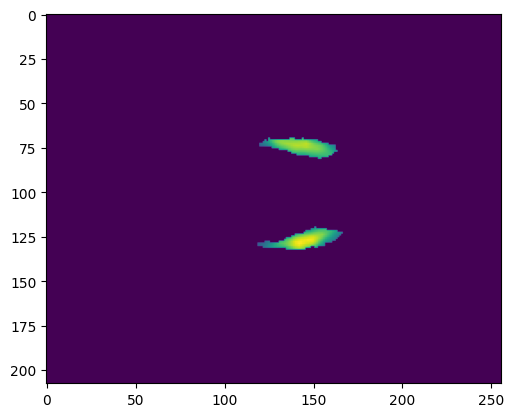

In [17]:
pet_masked = apply_mask_4d(image=pet.numpy(),mask=mask2)
plt.imshow(pet_masked[:,:,128,50])

In [18]:
def get_4d_image_where_regions(image: np.ndarray, segmentation: np.ndarray, regions: list):
    """Gets a mask from a list of regions in a segmentation and applies mask to 4D image."""
    regions_mask = get_regions_mask(segmentation=segmentation,regions=regions)
    masked_image = apply_mask_4d(image=image,mask=regions_mask)
    return masked_image

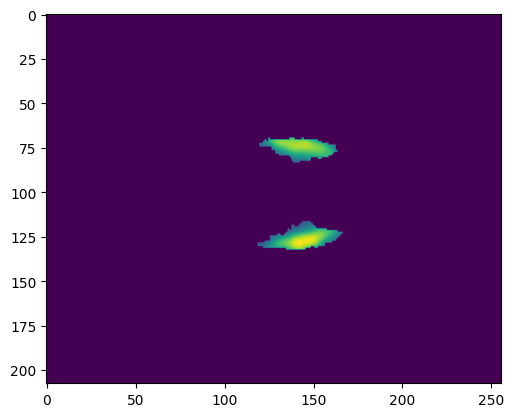

In [116]:
#pet_masked = get_4d_image_where_regions(image=pet.numpy(),segmentation=seg.numpy(),regions=[11,12,13,50,51,52])
pet_masked = get_4d_image_where_regions(image=pet.numpy(),segmentation=seg.numpy(),regions=[12,13,51,52])
plt.imshow(pet_masked[:,:,128,50])

In [117]:
xDim_aif, yDim_aif, zDim_aif, tDim = pet.shape
pet_data = pet_masked.reshape((xDim_aif*yDim_aif*zDim_aif, tDim))
neck_pca = sk_decomp.PCA(n_components=6, svd_solver='full')
neck_fit = neck_pca.fit_transform(pet_data)
pca_vals = neck_pca.components_[0].copy()

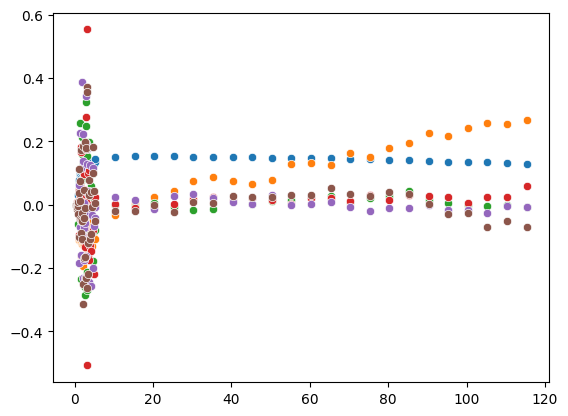

In [118]:
for i in range(6):
    sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[i])

In [119]:
neck_fit[100]

array([-2.89662429e+02,  2.84138191e+00,  1.15502676e-01,  2.99585916e-01,
       -6.97419878e-01,  4.93047284e-01])

In [120]:
pet_pca_z = zscore(neck_fit,axis=0)
pet_pca_fit = pet_pca_z.reshape((xDim_aif,yDim_aif,zDim_aif,6))

In [121]:
pet_pca_z[100]

array([-0.03316961,  0.00449255,  0.00026457,  0.0007142 , -0.00170091,
        0.0012392 ])

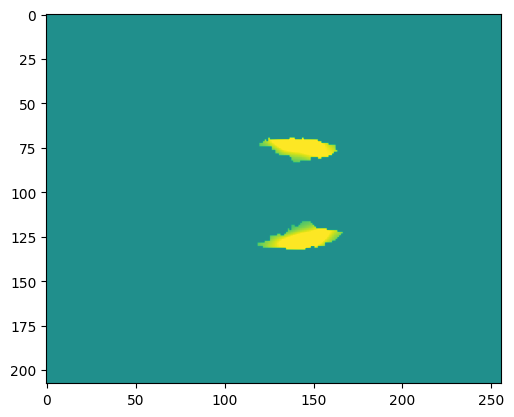

In [133]:
plt.imshow(pet_pca_fit[:,:,128,0],vmin=-30,vmax=30)

In [134]:
pet_kmeans = k_means(X=pet_pca_z,n_clusters=4)

In [135]:
pet_kmeans[0].shape

(4, 6)

In [136]:
pet_kmeans_reshaped = pet_kmeans[1].reshape((xDim_aif,yDim_aif,zDim_aif))

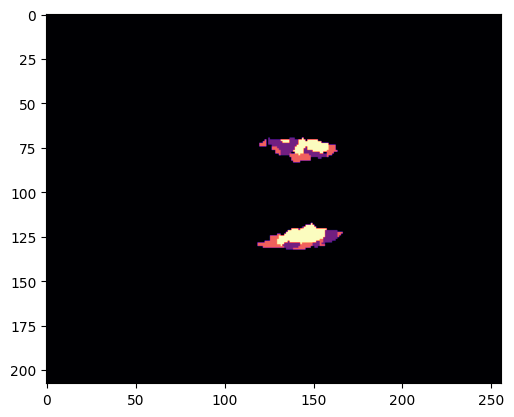

In [139]:
plt.imshow(pet_kmeans_reshaped[:,:,128],vmin=0,vmax=3,cmap='magma')

pet_kmeans_ants = ants.from_numpy(data=pet_kmeans_reshaped,origin=seg.origin,spacing=seg.spacing,direction=seg.direction)
ants.image_write(pet_kmeans_ants,filename='/tmp/pet_kmeans.nii.gz')

In [127]:
a = nibabel.load(filename=seg_file)
b = nibabel.nifti1.Nifti1Image(dataobj=pet_kmeans_reshaped,header=a.header,affine=a.affine)
nibabel.save(b,'/tmp/pet_kmeans.nii.gz')

In [140]:
tac0 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=0,verbose=False)
tac1 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=1,verbose=False)
tac2 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=2,verbose=False)
tac3 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=3,verbose=False)
#tac4 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=4,verbose=False)
#tac5 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=5,verbose=False)

<Axes: >

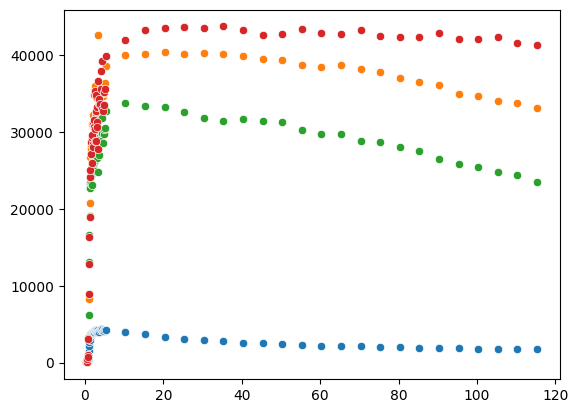

In [141]:
plt.figure()
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac0)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac1)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac2)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac3)
#sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac4)
#sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac5)

In [34]:
pet_pca_ants = ants.from_numpy(data=pet_pca_fit,origin=pet.origin,spacing=pet.spacing,direction=pet.direction)

In [35]:
ants.image_write(image=pet_pca_ants,filename='/tmp/pet_pca.nii.gz')

pet_masked = get_4d_image_where_regions(image=pet.numpy(),segmentation=seg.numpy(),regions=[7,8,46,47])
plt.figure()
plt.imshow(pet_masked[:,:,128,50])
plt.close()
xDim_aif, yDim_aif, zDim_aif, tDim = pet.shape
pet_data = pet_masked.reshape((xDim_aif*yDim_aif*zDim_aif, tDim))
neck_pca = sk_decomp.PCA(n_components=6, svd_solver='full')
neck_fit = neck_pca.fit_transform(pet_data)
pca_vals = neck_pca.components_[0].copy()
plt.figure()
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[0])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[1])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[2])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[3])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[4])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[5])
plt.close()
pet_pca_fit = neck_fit.reshape((xDim_aif,yDim_aif,zDim_aif,6))
pet_kmeans = k_means(X=neck_fit,n_clusters=6)
pet_kmeans_reshaped = pet_kmeans[1].reshape((xDim_aif,yDim_aif,zDim_aif))
plt.figure()
plt.imshow(pet_kmeans_reshaped[:,:,128],vmin=0,vmax=6,cmap='magma')
plt.close()
a = nibabel.load(filename=seg_file)
b = nibabel.nifti1.Nifti1Image(dataobj=pet_kmeans_reshaped,header=a.header,affine=a.affine)
nibabel.save(b,'/tmp/pet_kmeans.nii.gz')
tac0 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=0,verbose=False)
tac1 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=1,verbose=False)
tac2 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=2,verbose=False)
tac3 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=3,verbose=False)
tac4 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=4,verbose=False)
tac5 = extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),segmentation_image_numpy=pet_kmeans_reshaped,region=5,verbose=False)
plt.figure()
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac0)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac1)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac2)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac3)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac4)
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac5)

<Axes: >

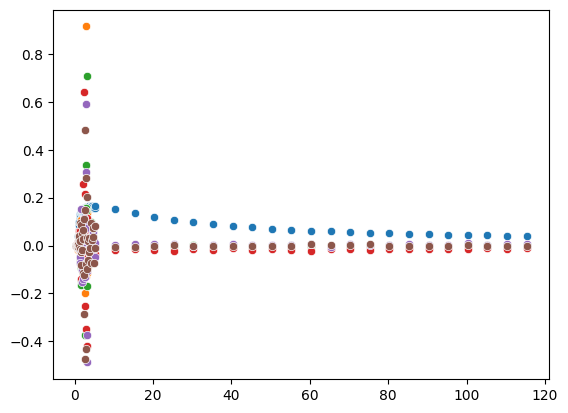

In [37]:
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[0])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[1])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[2])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[3])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[4])
sns.scatterplot(x=tac_example.tac_times_in_minutes,y=neck_pca.components_[5])

In [38]:
striatum_atlas_path = '/export/scratch1/goldmann/striatum-con-label-thr25-7sub-0p9mm.nii.gz'
#merge_path = '/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/14Nov24result/bp_merge.nii.gz'
merge_path = '/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/11Nov24result/bp_merge.nii.gz'
suvr_path = '/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/11Nov24result/suvr_merge.nii.gz'
striatum = ants.image_read(filename=striatum_atlas_path)
merge = ants.image_read(filename=merge_path)
suvr = ants.image_read(suvr_path)

In [39]:
tacs_cd = []
for region in range(1,8):
    tacs_cd += [extract_tac_from_nifty_using_mask(input_image_4d_numpy=merge.numpy()[:,:,:,:20],
                                      segmentation_image_numpy=striatum.numpy(),
                                      region=region,
                                      verbose=False)]

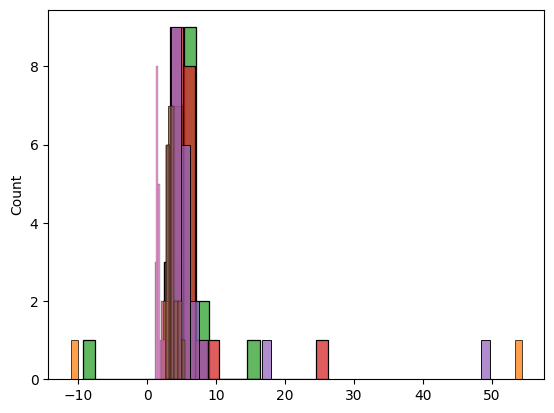

In [40]:
for tac in tacs_cd:
    sns.histplot(x=tac)

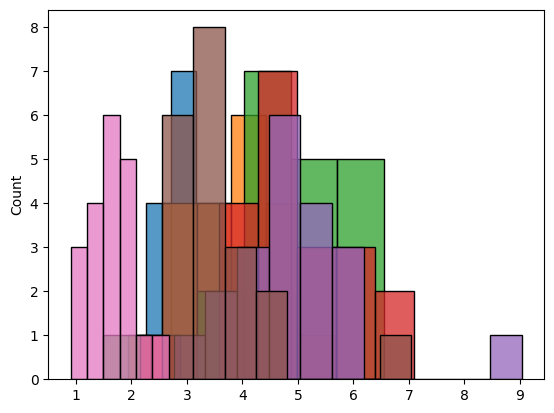

In [41]:
tacs_hc = []
for region in range(1,8):
    tacs_hc += [extract_tac_from_nifty_using_mask(input_image_4d_numpy=merge.numpy()[:,:,:,20:],
                                      segmentation_image_numpy=striatum.numpy(),
                                      region=region,
                                      verbose=False)]
for tac in tacs_hc:
    sns.histplot(x=tac)

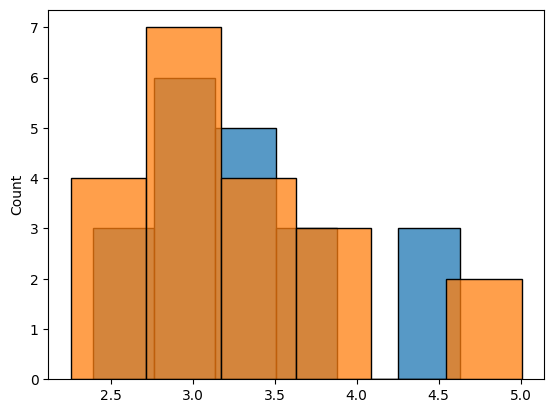

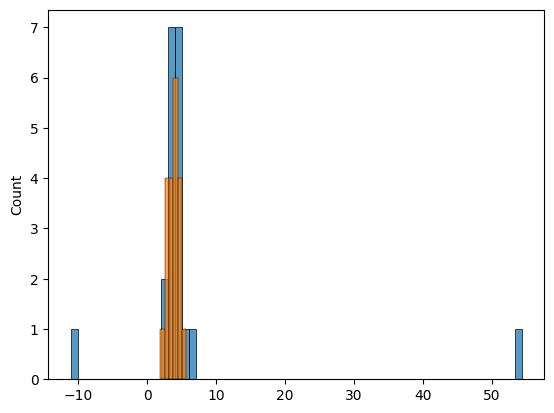

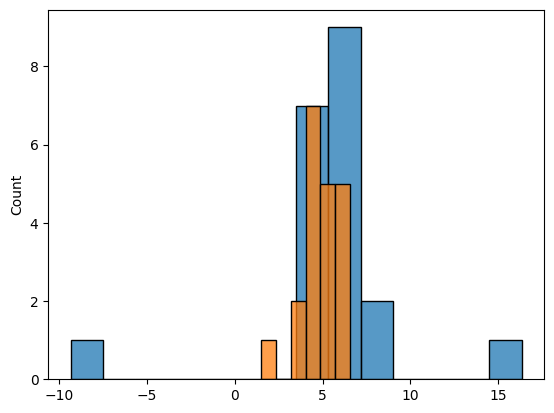

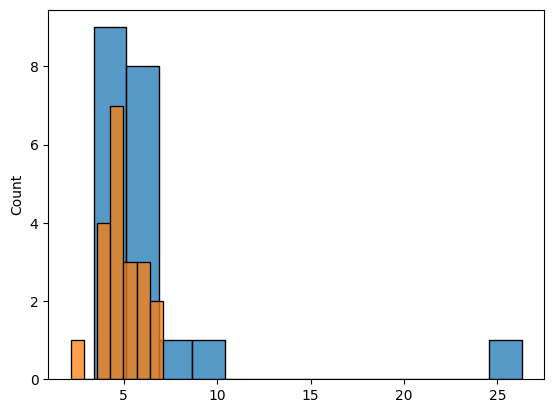

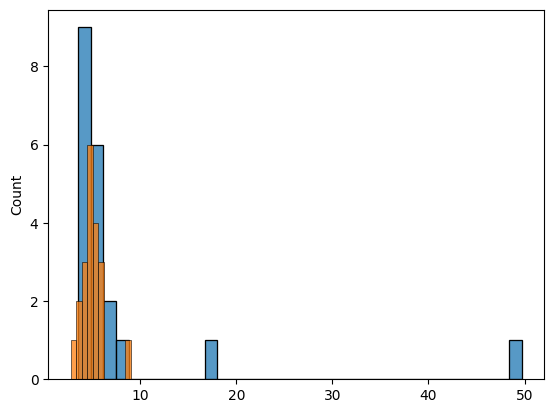

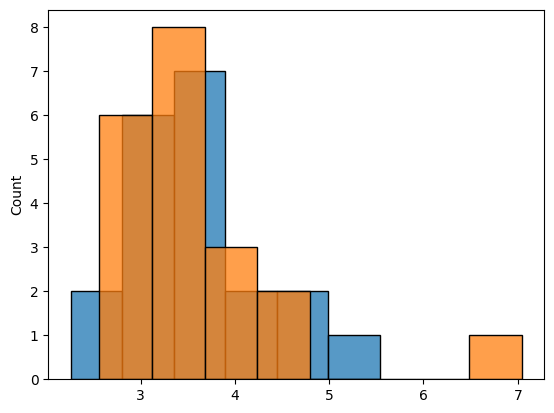

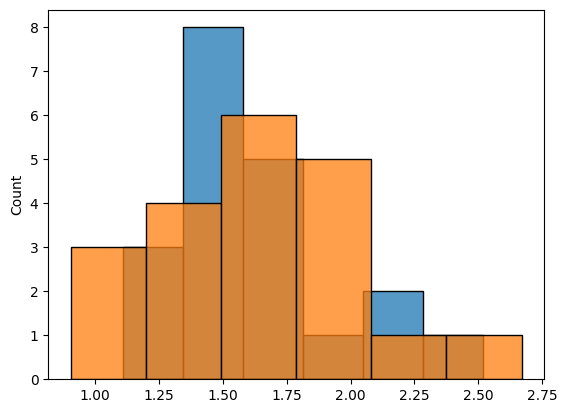

In [42]:
for i in range(7):
    plt.figure()
    sns.histplot(x=tacs_cd[i])
    sns.histplot(x=tacs_hc[i])

In [43]:
for i in range(7):
    print(ttest_ind(tacs_cd[i],tacs_hc[i],equal_var=False))

TtestResult(statistic=np.float64(0.299355150770713), pvalue=np.float64(0.7663221252956269), df=np.float64(37.496974751916206))
TtestResult(statistic=np.float64(0.7327944432766175), pvalue=np.float64(0.4725358993597131), df=np.float64(19.200510550141843))
TtestResult(statistic=np.float64(0.28461526865332465), pvalue=np.float64(0.7786538283217844), df=np.float64(21.56744646889111))
TtestResult(statistic=np.float64(1.3578037718905234), pvalue=np.float64(0.18896957710195733), df=np.float64(20.95332855074253))
TtestResult(statistic=np.float64(1.3391208549733233), pvalue=np.float64(0.19589283118509399), df=np.float64(19.551729351536324))
TtestResult(statistic=np.float64(0.04180215326421238), pvalue=np.float64(0.9668887911015837), df=np.float64(35.78478170107941))
TtestResult(statistic=np.float64(0.015456052319091931), pvalue=np.float64(0.9877509793378818), df=np.float64(37.18441513268824))


In [44]:
tform0 = ants.read_transform(filename='/export/scratch1/Registration/VATDYS/sub-VATDYS017/PRISMA_TRIO_PIB_NL_ANTS_NoT2/sub-VATDYS017_mpr_to_PRISMA_TRIO_PIB_NL_T1_ANTS0GenericAffine.mat').invert()
tform1 = ants.read_transform(filename='/export/scratch1/Registration/VATDYS/sub-VATDYS017/PRISMA_TRIO_PIB_NL_ANTS_NoT2/sub-VATDYS017_mpr_to_PRISMA_TRIO_PIB_NL_T1_ANTS1InverseWarp.nii.gz')
striatum0 = ants.apply_ants_transform_to_image(transform=tform0,image=striatum,reference=seg,interpolation='nearestneighbor')
#striatum0 = ants.apply_ants_transform_to_image(transform=tform1,image=striatum_reverse,reference=seg,interpolation='nearestneighbor')

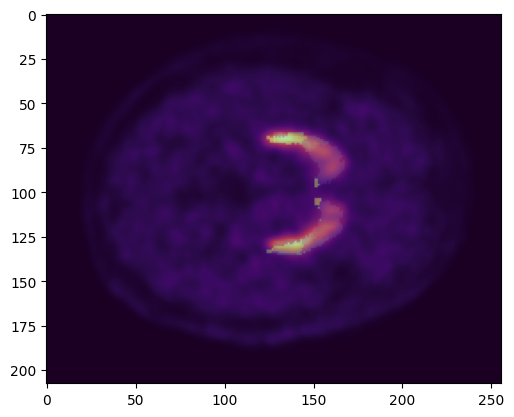

In [45]:
level = 120
plt.imshow(pet.numpy()[:,:,level,-1],cmap='magma')
plt.imshow(striatum0.numpy()[:,:,level],alpha=0.4)

In [46]:
tacs = []
for region in range(1,8):
    tacs += [extract_tac_from_nifty_using_mask(input_image_4d_numpy=pet.numpy(),
                                      segmentation_image_numpy=striatum0.numpy(),
                                      region=region,
                                      verbose=False)]

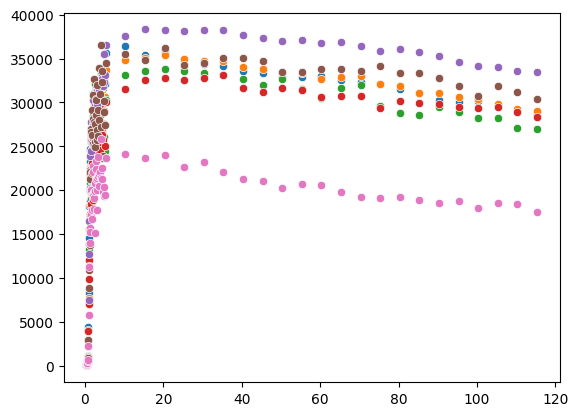

In [47]:
for tac in tacs:
    sns.scatterplot(x=tac_example.tac_times_in_minutes,y=tac)